In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rakeshrau/social-network-ads/Social_Network_Ads.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/rakeshrau/social-network-ads/Social_Network_Ads.csv")
df = df[["Age","EstimatedSalary","Purchased"]]
df.columns = ["Age","Income","BuyHouse"]
df.head()

,Age,Income,BuyHouse
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [3]:
# Splitting the features
x = df[["Age","Income"]]
y = df["BuyHouse"]

In [4]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    x,y,test_size=0.2,random_state=42
)

In [5]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [6]:
from sklearn.metrics import accuracy_score, confusion_matrix
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8375

Confusion Matrix
[[46  6]
 [ 7 21]]


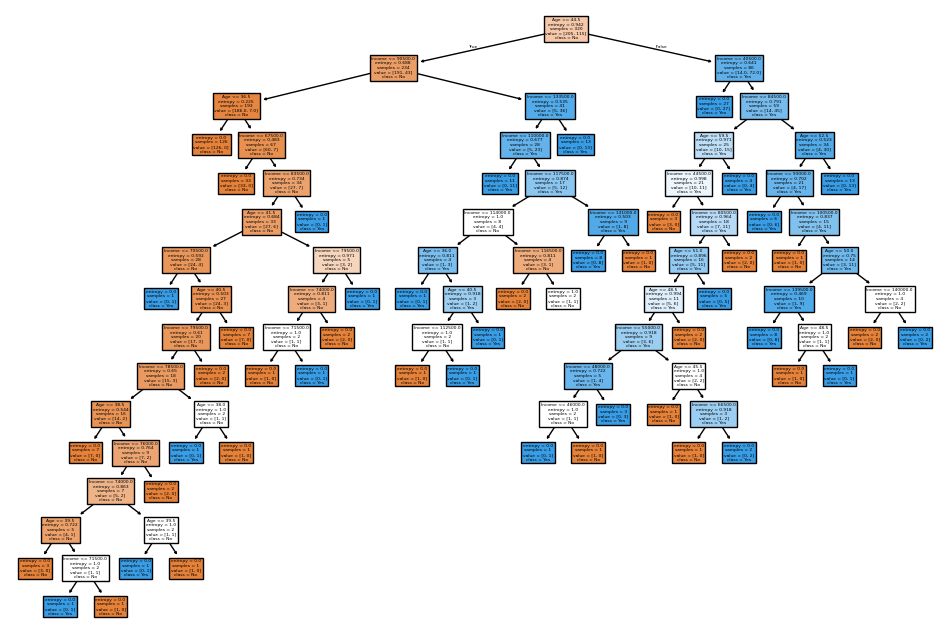

In [7]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(12,8))

plot_tree(
    model,
    feature_names=['Age', 'Income'],
    class_names=['No', 'Yes'],
    filled=True
)

plt.show()